# DashAnalysis Quickstart — Comprehensive Demo Notebook

This notebook provides a structured, end-to-end walkthrough of the DashAnalysis API with practical, reproducible examples. It expands the original quickstart to cover the full feature set demonstrated in the advanced notebook, including metadata inspection, flexible slicing, advanced visualization, line cuts (static and interactive), volume creation/visualization, and image-based workflows.

Core functions covered:

- da.load_data()
- data.metadata and da.show_meta()
- da.show_point_cloud()
- da.slice_data() with canonical planes, custom normals/origins, axes, slab_thickness, intensity_range
- da.show_slice() with axis_display, grid, intensity limits, return_image
- da.line_cut() with presets, custom endpoints, width averaging, interactive mode
- da.create_vol() and da.show_vol()

Each section includes comments and code you can adapt.

# Setup: imports, notebook backend, and robust DashAnalysis import

In [3]:
%matplotlib widget

import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
pv.set_jupyter_backend('html')


In [4]:
# Robust import pattern: use installed module if present; otherwise import from utils
dash = None
try:
    import dash_analysis as dash
except ModuleNotFoundError:
    try:
        import sys
        import os
        notebook_dir = os.getcwd()
        parent_dir = os.path.dirname(os.path.dirname(notebook_dir))
        if parent_dir not in sys.path:
            sys.path.append(parent_dir)
        from utils import dash_analysis as dash
        print("Successfully imported dash_analysis from utils")
    except ImportError as e:
        print(f"Failed to import dash_analysis: {e}")

# Create analysis instance
da = dash.DashAnalysis()


Successfully imported dash_analysis from utils


## Load data (da.load_data) and inspect metadata

We use a known dummy HDF5 file in this repo to ensure reproducibility. If you have a real file, set `filename` accordingly.

In [5]:
# Use the repo's dummy data by default; change this to your data file if available
filename = "/home/beams/OODIASEIGIEHON/DashPVA/dummy/DUMMY_POINT_DATA.h5"

# Load
# PASS
data = da.load_data(filename)


### Metadata overview (data.metadata and da.show_meta)

You can access a metadata dict on the Data object and also request formatted metadata via `da.show_meta()`.

In [6]:
# Inspect a specific metadata key (example: grid)
try:
    print("Metadata keys:", list(data.metadata.keys())[:10])
    print("Grid metadata:", data.metadata.get('grid'))
except Exception as e:
    print("No metadata available on Data object:", e)

# Show formatted metadata (text or dict)
_ = da.show_meta(filename, style="text")
_ = da.show_meta(filename, style="dict")
# _ = da.show_meta(filename, style="json")  # if you prefer JSON-style output


Metadata keys: ['summary', 'grid', 'volume', 'datasets', 'entry_attrs', 'data_attrs', 'other_metadata']
Grid metadata: {'voxel_spacing': None, 'grid_origin': None, 'grid_dimensions_cells': None, 'grid_dimensions_points': None, 'array_order': 'F', 'axes_labels': ['H', 'K', 'L']}


## Point cloud visualization (basic and advanced)

Render the HKL point cloud for a quick look. In notebook mode, rendering automatically caps at 5 million points for interactivity.

In [ ]:
# Basic point cloud rendering (Data object)
# Note: pass opacity_range to avoid LUT range issues
da.show_point_cloud(
    data,
    cmap='viridis',
    point_size=1.5,
    opacity=0.15,
    opacity_range=(0.0, 1.0),
    render_points_as_spheres=False,
    show_bounds=True
)

# Advanced point cloud rendering with intensity range and spherical glyphs
# You can also pass (points, intensities) explicitly
da.show_point_cloud(
    (data.points, data.intensities),
    clim=(100.0, 50000.0),            # controls color scaling
    cmap='jet',
    point_size=2.0,
    opacity=1.0,
    opacity_range=(0.2, 0.8),         # intensity-based opacity range
    render_points_as_spheres=True,
    axes_labels=('H','K','L'),
    show_bounds=True
)

print(f"Points: {data.points.shape}, Intensities range: {float(np.min(data.intensities)):.2f} - {float(np.max(data.intensities)):.2f}")


Converted to poly data
Notebook mode: capped point cloud from 31457280 to 5000000 by top intensities.


2025-12-18 10:27:53.123 (  21.150s) [    7F29B9F22740]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

Converted to poly data
Notebook mode: capped point cloud from 31457280 to 5000000 by top intensities.


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

Points: (31457280, 3), Intensities range: 0.00 - 47.72


: 

## Create and display 2D slices — multiple modes

Demonstrate canonical planes, custom normals/origins, custom HKL axes, slab thickness, and intensity-based filtering.

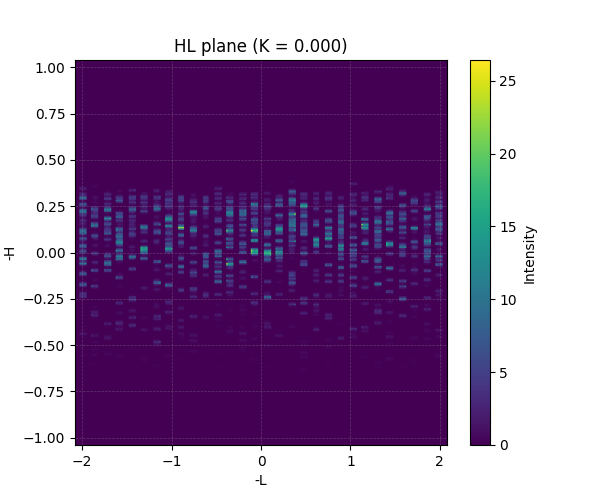

In [7]:
# 1) Canonical HL plane with grid and HKL labels
#    HL plane: U=H, V=L, normal aligned with K
sl_hl = da.slice_data(
    data=data,
    hkl='HL',                 # HL plane preset
    shape=(256, 256),         # raster resolution (rows, cols)
    show=True,                # display via show_slice
    axis_display='hkl',       # formatted HKL labels
    show_grid=True
)


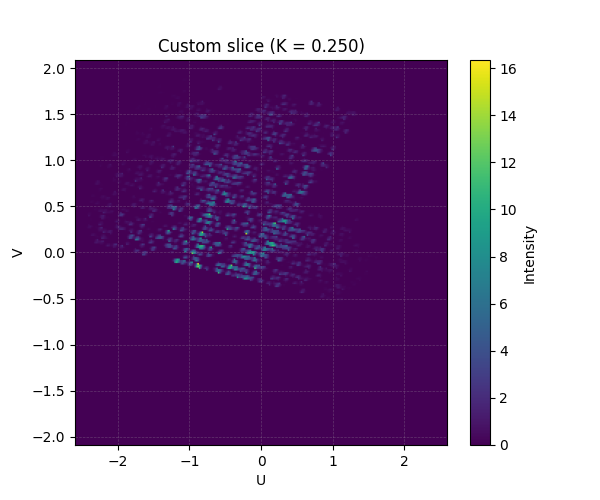

In [8]:
# 2) Custom plane: specify origin (H,K,L) and normal vector
sl_custom_plane = da.slice_data(
    data=data,
    hkl=(0.40, 0.25, 0.70),   # plane origin in HKL
    normal=(0.1, 0.9, 0.3),   # plane normal
    shape=(256, 256),
    show=True,
    axis_display='uv',        # display U/V labels
    show_grid=True
)


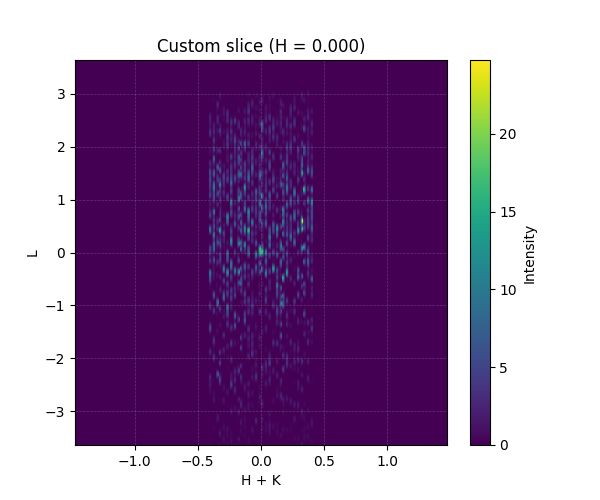

Stored slice_shape: [300 300]
U-axis label: H + K
V-axis label: L


In [9]:
# 3) Custom HKL in-plane axes with automatic axis labeling
#    Provide (u_hkl, v_hkl) and optionally normal; labels are formatted and stored on the slice
sl_axes = da.slice_data(
    data=data,
    axes=((1, 1, 0), (0, 0, 1), (1, -1, 0)),  # u = H+K, v = L; normal provided
    shape=(300, 300),
    show=True,
    axis_display='hkl',
    show_grid=True
)
try:
    print("Stored slice_shape:", sl_axes.field_data.get('slice_shape'))
    print("U-axis label:", sl_axes.field_data.get('slice_u_label'))
    print("V-axis label:", sl_axes.field_data.get('slice_v_label'))
except Exception as e:
    print("Axis labels not available:", e)


/home/beams0/OODIASEIGIEHON/DashPVA/utils/dash_analysis.py:635: UserWarning: slice_data: intensity_range and/or slab_thickness excluded all points; returning empty slice.
  _warnings.warn("slice_data: intensity_range and/or slab_thickness excluded all points; returning empty slice.")


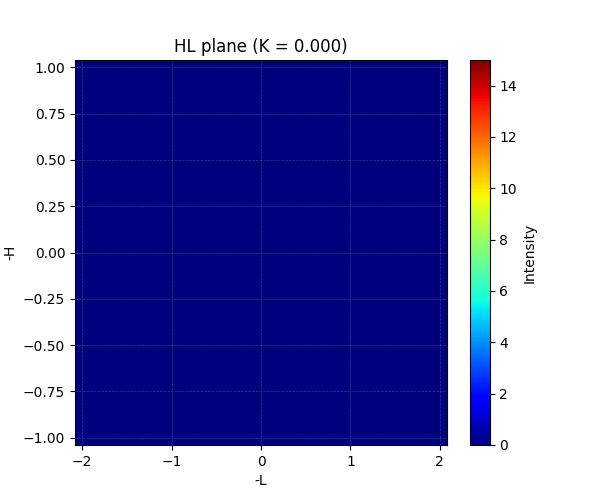

In [ ]:
# 4) Thick slab selection around a plane with intensity filtering
#    Use slab_thickness to include points within ±thickness of plane
sl_slab = da.slice_data(
    data=(data.points, data.intensities),
    hkl='HL',                  # HL plane
    shape=(512, 512),
    #slab_thickness=3.0,        # include points within ±2.0 of plane (remove)
    intensity_range=(11,15),  # pre-filter contributing points (remove)
    show=False                 # we'll render separately with custom display limits
)

da.show_slice(
    sl_slab,
    cmap='jet',
    clim=(0, 15),           # display limits
    min_intensity=None,
    max_intensity=None,
    axis_display='hkl',
    show_grid=True
)


## Working with returned slice images

You can request a raster image and physical extent from show_slice and reuse them directly for line cuts.

In [ ]:
img, extent = da.show_slice(sl_axes, return_image=True)
print("Returned image shape:", img.shape)
print("Extent [Umin, Umax, Vmin, Vmax]:", extent)


## Line cuts — presets, custom endpoints, width averaging, interactive mode

Line cuts can operate on a cached image (from the most recent show_slice), on a `(img, extent)` pair, or on a slice mesh. Demonstrated below:

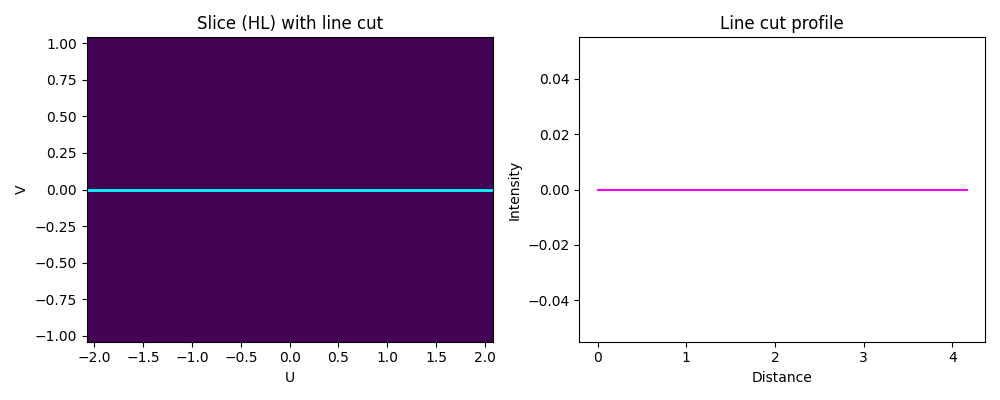

In [11]:
# 1) Horizontal line cut at fixed V ("zero" preset)
lc_zero = da.line_cut(
    'zero',
    param=(0.0, 'x'),     # V fixed at 0.0; traverse U across full extent
    n_samples=256,
    width_px=1,
    show=True             # draws overlay + profile
)


In [ ]:
# 2) Vertical line cut at fixed U ("infinite" preset) using the returned image directly
lc_inf = da.line_cut(
    'infinite',
    param=(0.0, 'y'),     # U fixed at 0.0; traverse V across full extent
    vol=(img, extent),
    n_samples=512,
    width_px=3,
    show=True
)


In [ ]:
# 3) Diagonals across the full slice extent
lc_pos = da.line_cut(
    'positive',
    n_samples=512,
    width_px=3,
    show=True
)

lc_neg = da.line_cut(
    'negative',
    n_samples=512,
    width_px=3,
    show=True
)

print('Positive cut samples:', len(lc_pos['distance']))


In [ ]:
# 4) Custom endpoints in U/V coordinates
lc_custom = da.line_cut(
    ((-0.25, -0.25), (0.25, 0.40)),  # endpoints in physical slice coordinates
    vol=(img, extent),
    n_samples=512,
    width_px=2,
    show=True
)


In [ ]:
# 5) Interactive line cut with draggable endpoints (requires interactive matplotlib backend)
#    Ensure the first cell used '%matplotlib widget' and that 'ipympl' is installed.
#    You can drag the cyan endpoints and the magenta profile updates in real-time.
lc_interactive = da.line_cut(
    'positive',
    vol=(img, extent),
    interactive=True,
    n_samples=256,
    width_px=3
)


## Volume creation and visualization

Convert the point cloud to a structured volume and visualize it, then slice that volume.

In [ ]:
# Create a 3D volume from points
vol = da.create_vol(data.points, data.intensities)
print("Created volume dimensions:", vol.dimensions)
print("Volume spacing:", vol.spacing)
print("Volume origin:", vol.origin)

# Visualize the volume
# Tip: try different colormaps like 'plasma', 'viridis', 'jet'
da.show_vol(vol, cmap='plasma')

# Slice the volume directly (canonical HL plane)
sl_from_vol = da.slice_data(
    data=vol,
    hkl='HL',
    shape=(400, 400),
    intensity_range=(None, None),   # no pre-filtering
    show=True,
    axis_display='hkl',
    show_grid=True
)


## Enhanced slice visualization options

Use min/max intensity thresholds and clim for display; switch label format; keep per-pixel physical size consistent when changing shape.

In [ ]:
# Display with custom limits and HKL labels
_ = da.show_slice(
    sl_from_vol,
    cmap='coolwarm',
    clim=(0, 10000),
    min_intensity=100,          # filter out low intensity pixels
    max_intensity=50000,        # cap high intensity
    axis_display='hkl',
    show_grid=True,
    shape_data=True             # keep physical size per pixel when reshaping
)

# Display with U/V labels
_ = da.show_slice(
    sl_from_vol,
    cmap='viridis',
    axis_display='uv',
    show_grid=False
)


## Image-based workflow recap

Get the image/extent, perform line cuts without re-slicing, and reuse cached data for subsequent operations.

In [ ]:
img2, extent2 = da.show_slice(sl_from_vol, return_image=True)
lc_from_image = da.line_cut(
    'zero',
    param=(0.0, 'x'),
    vol=(img2, extent2),
    n_samples=300,
    width_px=3,
    show=True
)


## Tips & Notes

- Interactive line cuts require an interactive Matplotlib backend. Use `%matplotlib widget` (preferred; requires `ipympl`) or `%matplotlib notebook`.
- Explore different planes via `hkl` presets ('HK', 'KL', 'HL') or specify `normal=(h,k,l)` and/or a custom origin.
- Use `axes=((h1,k1,l1), (h2,k2,l2))` to define custom in-plane HKL axes with automatic axis labels. Optionally add a third vector for the plane normal.
- `slab_thickness` selects points within a thick slice around the plane; combine with `intensity_range=(min, max)` for pre-filtering before interpolation.
- `show_slice(..., return_image=True)` returns `(img, extent)` for downstream processing (e.g., line cuts) without re-slicing.
- `create_vol` converts point clouds to a structured volume suitable for volume rendering and volume-based slicing.

## Summary

This comprehensive quickstart demonstrated:

1. Loading data and inspecting metadata (dict/text/JSON styles)
2. 3D point cloud visualization with intensity-based opacity and bounds
3. Flexible 2D slicing from point clouds and volumes (presets, custom normals/origins, custom axes)
4. Enhanced slice display controls (labels, grids, intensity thresholds, display limits)
5. Line cuts with presets, custom endpoints, width averaging, and interactive mode
6. Volume creation and visualization, followed by slicing and image-based workflows

Use these building blocks to explore complex HKL datasets efficiently and reproducibly.